In [ ]:
import pandas as pd
from google.colab import files
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

Saving events.csv to events.csv


In [ ]:
df = pd.read_csv('events.csv')
display(df.head(20))

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ
5,2020-09-24 11:57:59 UTC,view,664325,2144415951611757447,construction.tools.saw,carver,52.33,1515915625519388062,vnkdP81DDW
6,2020-09-24 11:58:23 UTC,view,3791349,2144415935086199225,computers.desktop,NaN,215.41,1515915625519388877,J1t6sIYXiV
7,2020-09-24 11:58:24 UTC,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kVBeYDPcBw
8,2020-09-24 11:58:25 UTC,view,657859,2144415939431498289,NaN,NaN,34.17,1515915625519320570,HEl15U7JVy
9,2020-09-24 11:58:31 UTC,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388929,F3VB9LYp39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [ ]:
event_types = df['event_type'].value_counts()
display(event_types)

,count
event_type,
view,793748
cart,54035
purchase,37346


In [ ]:
# Рахуємо кількість пропусків у кожній колонці
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Об'єднуємо в красиву табличку
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Кількість пропусків', '% пропусків'])
display(missing_table)

,Кількість пропусків,% пропусків
event_time,0,0.000000
event_type,0,0.000000
product_id,0,0.000000
category_id,0,0.000000
category_code,236219,26.687522
brand,212364,23.992435
price,0,0.000000
user_id,0,0.000000
user_session,165,0.018641


In [ ]:
# Замінюємо всі пропущені значення в текстових колонках на 'unknown'
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')
df['user_session'] = df['user_session'].fillna('unknown')

# Перевіряємо ще раз, чи залишилися пропуски
print("Кількість пропусків після очищення:")
print(df.isnull().sum())

Кількість пропусків після очищення:
event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


In [ ]:
# Конвертуємо event_time у datetime
df['event_time'] = pd.to_datetime(df['event_time'])

# Визначаємо часові межі
min_date = df['event_time'].min()
max_date = df['event_time'].max()

print(f"\nДані зібрані за період з: {min_date}")
print(f"Дані зібрані за період по: {max_date}")
print(f"Загальна тривалість датасету: {max_date - min_date}")


Дані зібрані за період з: 2020-09-24 11:57:06+00:00
Дані зібрані за період по: 2021-02-28 23:59:09+00:00
Загальна тривалість датасету: 157 days 12:02:03


In [ ]:
# 1. Створюємо колонку з тижнем події
# .dt.to_period('W') округлює дату до початку відповідного тижня
df['event_week'] = df['event_time'].dt.to_period('W')

# 2. Знаходимо тиждень НАЙПЕРШОЇ активності для кожного користувача
df['cohort_week'] = df.groupby('user_id')['event_week'].transform('min')

# 3. Рахуємо різницю в тижнях (Cohort Index)
# Переводимо у формат рядка або timestamp для числових обчислень
df['cohort_index'] = (df['event_week'] - df['cohort_week']).apply(lambda x: x.n)

# Подивимося, які унікальні тижні життя користувачів ми маємо
print("Унікальні тижні утримання (від 0 до макс):")
print(sorted(df['cohort_index'].unique()))

# Глянемо на проміжний результат
df[['user_id', 'event_week', 'cohort_week', 'cohort_index']].head()

/tmp/ipykernel_6162/2509916844.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['event_week'] = df['event_time'].dt.to_period('W')


Унікальні тижні утримання (від 0 до макс):
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]


,user_id,event_week,cohort_week,cohort_index
0,1515915625519388267,2020-09-21/2020-09-27,2020-09-21/2020-09-27,0
1,1515915625519380411,2020-09-21/2020-09-27,2020-09-21/2020-09-27,0
2,1515915625513238515,2020-09-21/2020-09-27,2020-09-21/2020-09-27,0
3,1515915625519014356,2020-09-21/2020-09-27,2020-09-21/2020-09-27,0
4,1515915625510743344,2020-09-21/2020-09-27,2020-09-21/2020-09-27,0


In [ ]:
# 1. Групуємо дані за тижнем когорти та індексом утримання, рахуємо унікальних користувачів
cohort_data = df.groupby(['cohort_week', 'cohort_index'])['user_id'].nunique().reset_index()

# 2. Переформатовуємо таблицю у зведену (Pivot Table)
cohort_counts = cohort_data.pivot(index='cohort_week', columns='cohort_index', values='user_id')

# 3. Виділяємо розмір когорти (стовпчик з індексом 0 — це кількість людей на старті)
cohort_sizes = cohort_counts.iloc[:, 0]

# 4. Ділимо кожен рядок на початковий розмір когорти, щоб отримати відсотки (Retention Rate)
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

# Округлюємо для красивого відображення (наприклад, до 3 знаків після коми)
retention_matrix = retention_matrix.round(3)

# Виведемо матрицю в абсолютних значеннях (кількість людей)
print("Матриця утримання в кількості користувачів:")
display(cohort_counts.head())

# Виведемо матрицю у відсотках (Retention Rate)
print("\nМатриця Retention Rate (у відсотках):")
display(retention_matrix.head())

Матриця утримання в кількості користувачів:


cohort_index,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
cohort_week,,,,,,,,,,,,,,,,,,,,,
2020-09-21/2020-09-27,7691.0,428.0,202.0,138.0,127.0,91.0,69.0,65.0,54.0,38.0,...,22.0,17.0,22.0,13.0,18.0,7.0,16.0,16.0,14.0,8.0
2020-09-28/2020-10-04,16563.0,509.0,226.0,195.0,118.0,102.0,86.0,65.0,55.0,50.0,...,19.0,28.0,36.0,22.0,24.0,28.0,19.0,21.0,13.0,NaN
2020-10-05/2020-10-11,15982.0,445.0,179.0,126.0,103.0,86.0,71.0,50.0,39.0,32.0,...,22.0,30.0,20.0,25.0,18.0,15.0,15.0,12.0,NaN,NaN
2020-10-12/2020-10-18,19143.0,518.0,210.0,174.0,106.0,85.0,49.0,36.0,32.0,30.0,...,32.0,20.0,24.0,26.0,14.0,15.0,13.0,NaN,NaN,NaN
2020-10-19/2020-10-25,21095.0,558.0,264.0,182.0,133.0,93.0,83.0,54.0,52.0,48.0,...,29.0,31.0,29.0,26.0,32.0,23.0,NaN,NaN,NaN,NaN



Матриця Retention Rate (у відсотках):


cohort_index,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
cohort_week,,,,,,,,,,,,,,,,,,,,,
2020-09-21/2020-09-27,1.0,0.056,0.026,0.018,0.017,0.012,0.009,0.008,0.007,0.005,...,0.003,0.002,0.003,0.002,0.002,0.001,0.002,0.002,0.002,0.001
2020-09-28/2020-10-04,1.0,0.031,0.014,0.012,0.007,0.006,0.005,0.004,0.003,0.003,...,0.001,0.002,0.002,0.001,0.001,0.002,0.001,0.001,0.001,NaN
2020-10-05/2020-10-11,1.0,0.028,0.011,0.008,0.006,0.005,0.004,0.003,0.002,0.002,...,0.001,0.002,0.001,0.002,0.001,0.001,0.001,0.001,NaN,NaN
2020-10-12/2020-10-18,1.0,0.027,0.011,0.009,0.006,0.004,0.003,0.002,0.002,0.002,...,0.002,0.001,0.001,0.001,0.001,0.001,0.001,NaN,NaN,NaN
2020-10-19/2020-10-25,1.0,0.026,0.013,0.009,0.006,0.004,0.004,0.003,0.002,0.002,...,0.001,0.001,0.001,0.001,0.002,0.001,NaN,NaN,NaN,NaN


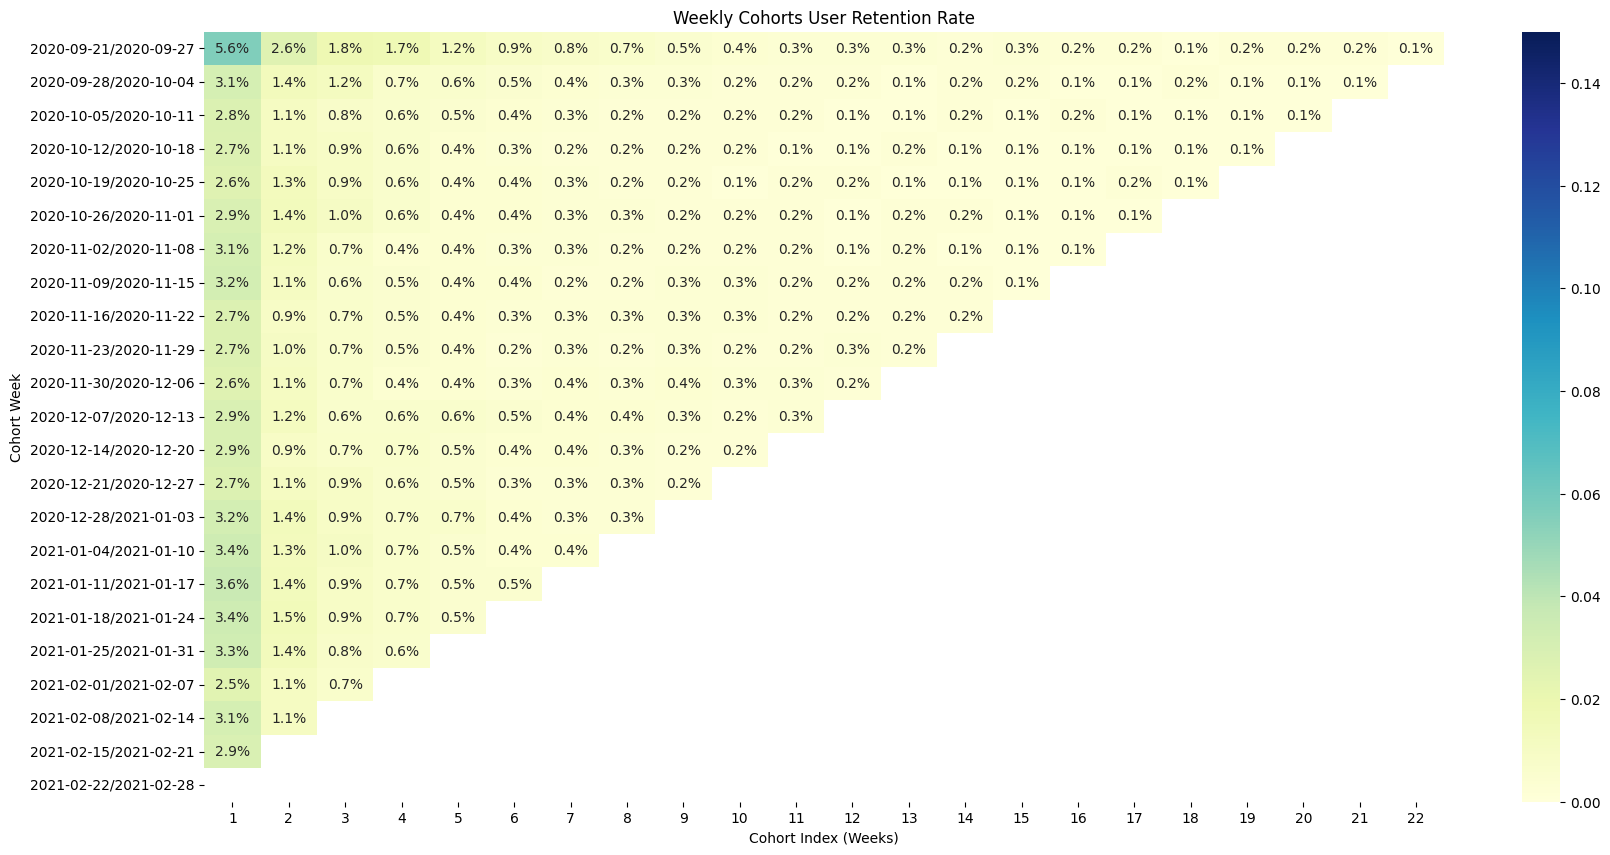

In [ ]:
plt.figure(figsize=(20, 10))
plt.title('Weekly Cohorts User Retention Rate')

# Будуємо heatmap, пропускаємо нульовий стовпчик (бо там всюди 100%), щоб краще бачити різницю на наступних етапах
sns.heatmap(retention_matrix.iloc[:, 1:], annot=True, fmt='.1%', cmap='YlGnBu', vmin=0.0, vmax=0.15)
plt.ylabel('Cohort Week')
plt.xlabel('Cohort Index (Weeks)')
plt.show()

In [ ]:
# 1. Скидаємо індекси зведеної таблиці та перетворюємо її з широкого формату на довгий (unpivot/melt)
# Беремо саме абсолютні значення (кількість людей), бо BI-інструмент сам легко порахує відсотки
bi_data = cohort_counts.reset_index().melt(id_vars='cohort_week', var_name='cohort_index', value_name='active_users')

# 2. Очистимо від порожніх значень (NaN), де тижні ще не настали
bi_data = bi_data.dropna()

# 3. Перетворимо періоди у звичайні рядки, щоб BI-інструменти розпізнали дату
bi_data['cohort_week'] = bi_data['cohort_week'].astype(str)

# Подивимося на формат, який "люблять" дашборди
display(bi_data.head(10))

# 4. Зберігаємо результат у новий файл для дашборду
bi_data.to_csv('cohort_retention_for_bi.csv', index=False)

,cohort_week,cohort_index,active_users
0,2020-09-21/2020-09-27,0,7691.0
1,2020-09-28/2020-10-04,0,16563.0
2,2020-10-05/2020-10-11,0,15982.0
3,2020-10-12/2020-10-18,0,19143.0
4,2020-10-19/2020-10-25,0,21095.0
5,2020-10-26/2020-11-01,0,20860.0
6,2020-11-02/2020-11-08,0,22133.0
7,2020-11-09/2020-11-15,0,22667.0
8,2020-11-16/2020-11-22,0,23540.0
9,2020-11-23/2020-11-29,0,16596.0


In [ ]:
from google.colab import files
files.download('cohort_retention_for_bi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Готуємо дані для воронки (кількість унікальних користувачів на кожен івент)
funnel = df.groupby('event_type')['user_id'].nunique().reset_index()
funnel.columns = ['metric_name', 'value']
funnel['metric_type'] = 'funnel_unique_users'

# 2. Готуємо дані для фінансових KPI (сумарні константи з логів покупок)
purchases_only = df[df['event_type'] == 'purchase']

kpi_data = pd.DataFrame({
    'metric_name': ['total_revenue', 'total_orders', 'aov'],
    'value': [
        purchases_only['price'].sum(),                     # $5,125,395.62
        purchases_only['user_session'].nunique(),          # 24,344 orders
        purchases_only['price'].sum() / purchases_only['user_session'].nunique() # $210.54 AOV
    ],
    'metric_type': ['financial_kpi', 'financial_kpi', 'financial_kpi']
})

# 3. Об'єднуємо все в один легкий, акуратний файл констант та воронки
final_bi_metrics = pd.concat([funnel, kpi_data], ignore_index=True)

# Дивимося на результат
print("Ось як виглядає твій універсальний файл для KPI та воронки:")
display(final_bi_metrics)

# 4. Зберігаємо та скачуємо на ПК
final_bi_metrics.to_csv('funnel_and_kpi_data.csv', index=False)

Ось як виглядає твій універсальний файл для KPI та воронки:


,metric_name,value,metric_type
0,cart,3.695200e+04,funnel_unique_users
1,purchase,2.130400e+04,funnel_unique_users
2,view,4.068630e+05,funnel_unique_users
3,total_revenue,5.125396e+06,financial_kpi
4,total_orders,2.434400e+04,financial_kpi
5,aov,2.105404e+02,financial_kpi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('funnel_and_kpi_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>